# Numeric predictors: scale, sentinels and stability

This focused notebook completes the initial **numeric** review of
`gps_height`, `num_private`, `population`. It describes the supplied training and test predictors,
then uses the labelled training rows to identify relationships worth
carrying into a leakage-safe modelling pipeline.

The audit keeps true numeric magnitude separate from encoded identifiers such as region codes.

This is exploratory evidence, not fitted preprocessing. Category pooling,
imputation, encoding and scaling must be learned inside each training fold.


## Consistent audit contract

Every focused predictor audit answers the same questions before adding
type-specific checks:

1. What is explicitly missing, and what looks like a sentinel?
2. What range or category coverage is present in training and test?
3. How much of the test set is exposed to unseen training levels?
4. Does the labelled distribution vary enough to justify retaining the field?
5. What exact baseline treatment follows from the evidence?

Target-rate tables flag support rather than treating tiny groups as reliable.
Train/test comparisons are descriptive and do not use the hidden test labels.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

stage_directory = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "TrainingSetValues.csv").is_file()
)
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    MISSING_CATEGORY,
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    cramer_v,
    hierarchy_conflicts,
    hierarchy_summary,
    numeric_summary,
    numeric_target_summary,
    normalise_categories,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)
audited_features = ['gps_height', 'num_private', 'population']
assert set(audited_features).issubset(training_features.columns)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {len(audited_features)} predictors."
)


Validated 59,400 training rows and 14,850 test rows for 3 predictors.


## 1. Distribution and sentinel audit

The zero counts are shown for every field. Domain meaning determines whether
zero is missing: it is treated as a sentinel for elevation and population,
but remains merely suspicious for the undocumented `num_private` field.


In [2]:
numeric_sentinels = {
    "gps_height": [0],
    "num_private": [],
    "population": [0],
}
display(
    numeric_summary(
        training_features,
        test_features,
        audited_features,
        sentinel_values_by_column=numeric_sentinels,
    )
)


rows  missing  sentinel rows  zero rows  negative rows  \
feature     frame                                                               
gps_height  training  59400        0          20438      20438           1496   
            test      14850        0           5211       5211            385   
num_private training  59400        0              0      58643              0   
            test      14850        0              0      14656              0   
population  training  59400        0          21381      21381              0   
            test      14850        0           5453       5453              0   

                      unique  minimum   p01  median     mean      p99  \
feature     frame                                                       
gps_height  training    2428      -90 -22.0   369.0  668.297  2142.00   
            test        2157      -57 -23.0   344.0  655.148  2140.00   
num_private training      65        0   0.0     0.0    0.474     5.00   
            test          36        0   0.0     0.0    0.415     4.00   
population  training    1049        0   0.0    25.0  179.910  2000.00   
            test         637        0   0.0    20.0  184.114  2001.02   

                      maximum  skewness  
feature     frame                        
gps_height  training     2770     0.462  
            test         2777     0.497  
num_private training     1776    91.934  
            test          669    50.745  
population  training    30500    12.661  
            test        11469     8.217

In [3]:
shared_zero = (
    training_features["gps_height"].eq(0)
    & training_features["population"].eq(0)
    & training_features["construction_year"].eq(0)
)
shared_zero_test = (
    test_features["gps_height"].eq(0)
    & test_features["population"].eq(0)
    & test_features["construction_year"].eq(0)
)
shared_measurement_state = pd.DataFrame({
    "training rows": [shared_zero.sum()],
    "training (%)": [shared_zero.mean() * 100],
    "test rows": [shared_zero_test.sum()],
    "test (%)": [shared_zero_test.mean() * 100],
    "height-zero rows also population-zero (%)": [
        training_features.loc[training_features["gps_height"].eq(0), "population"].eq(0).mean() * 100
    ],
    "height-zero rows also year-zero (%)": [
        training_features.loc[training_features["gps_height"].eq(0), "construction_year"].eq(0).mean() * 100
    ],
}, index=["shared zero-measurement block"]).round(3)
display(shared_measurement_state)


,training rows,training (%),test rows,test (%),height-zero rows also population-zero (%),height-zero rows also year-zero (%)
shared zero-measurement block,19668,33.111,5011,33.744,96.233,96.267


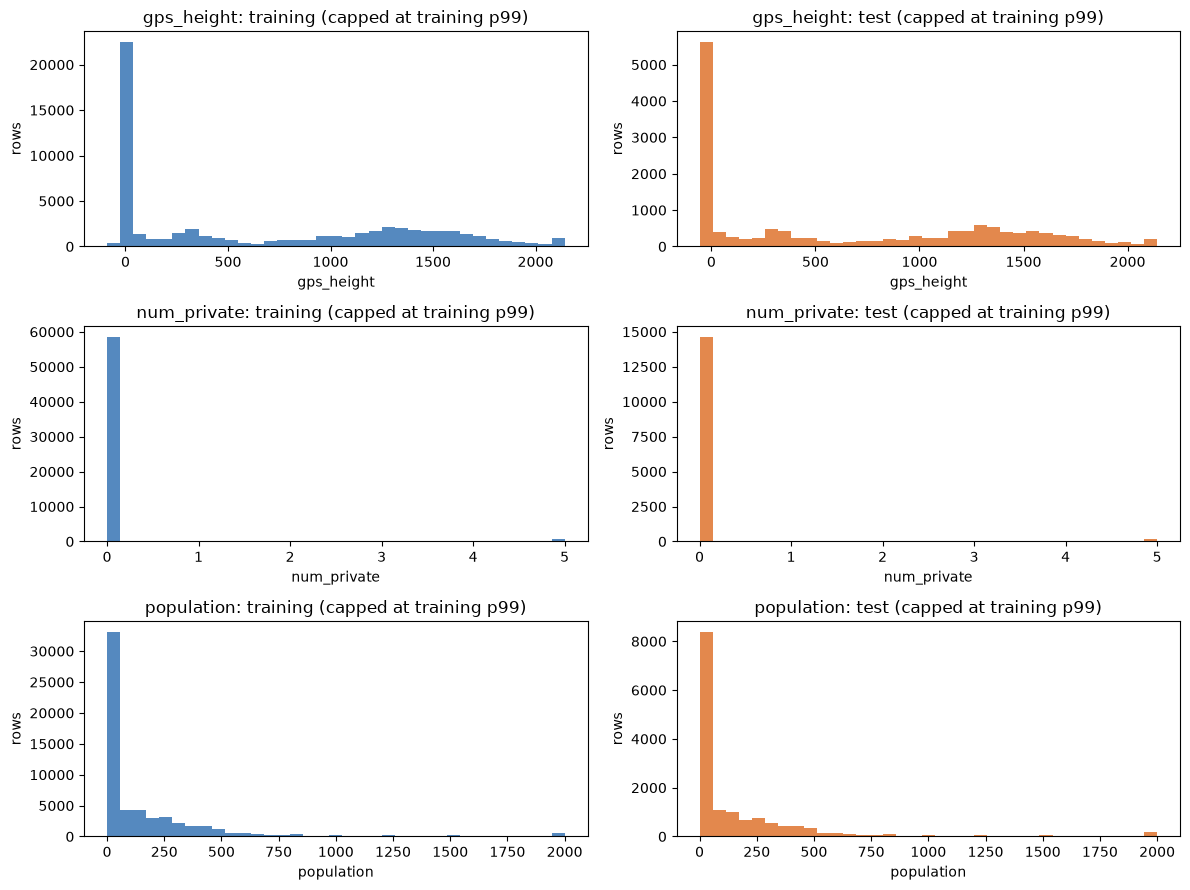

In [4]:
fig, axes = plt.subplots(len(audited_features), 2, figsize=(12, 9))
for row, feature in enumerate(audited_features):
    training_values = pd.to_numeric(training_features[feature], errors="coerce")
    test_values = pd.to_numeric(test_features[feature], errors="coerce")
    upper = training_values.quantile(0.99)
    for column, (label, values, colour) in enumerate(
        (("training", training_values, "#2b6cb0"), ("test", test_values, "#dd6b20"))
    ):
        axes[row, column].hist(values.clip(upper=upper), bins=35, color=colour, alpha=0.8)
        axes[row, column].set_title(f"{feature}: {label} (capped at training p99)")
        axes[row, column].set_xlabel(feature)
        axes[row, column].set_ylabel("rows")
plt.tight_layout()
plt.show()


## 2. Relationship with `status_group`

Medians and p90 values compare the numeric magnitude by class. The second
table isolates zero from positive values so a sentinel's apparent signal is
not mistaken for an ordinary numeric relationship.


In [5]:
for feature in audited_features:
    print()
    print(feature)
    display(
        numeric_target_summary(
            training_data,
            feature,
            sentinel_values=numeric_sentinels[feature],
        )
    )
    zero_state = np.where(training_data[feature].eq(0), "zero", "non-zero")
    zero_profile = pd.crosstab(
        zero_state,
        training_data["status_group"],
        normalize="index",
    ).mul(100).round(2)
    zero_profile.insert(0, "rows", pd.Series(zero_state).value_counts())
    display(zero_profile)



gps_height


,rows,missing,median,mean,sentinel rows,zero rows (%),p90
status_group,,,,,,,
functional,32259,0,550.0,740.131,10469,32.453,1714.0
functional needs repair,4317,0,385.0,627.607,1763,40.839,1538.4
non functional,22824,0,293.0,574.465,8206,35.953,1540.0


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
non-zero,38962,55.93,6.56,37.52
zero,20438,51.22,8.63,40.15



num_private


,rows,missing,median,mean,sentinel rows,zero rows (%),p90
status_group,,,,,,,
functional,32259,0,0.0,0.539,0,98.571,0.0
functional needs repair,4317,0,0.0,0.308,0,98.888,0.0
non functional,22824,0,0.0,0.414,0,98.913,0.0


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
non-zero,757,60.90,6.34,32.76
zero,58643,54.22,7.28,38.50



population


,rows,missing,median,mean,sentinel rows,zero rows (%),p90
status_group,,,,,,,
functional,32259,0,40.0,187.553,11274,34.948,460.0
functional needs repair,4317,0,25.0,175.102,1775,41.117,500.0
non functional,22824,0,1.0,170.016,8332,36.505,450.0


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
non-zero,38019,55.20,6.69,38.12
zero,21381,52.73,8.30,38.97


In [6]:
state_definitions = {
    "gps_height state": np.select(
        [training_data["gps_height"].lt(0), training_data["gps_height"].eq(0)],
        ["negative", "zero"],
        default="positive",
    ),
    "num_private state": np.where(training_data["num_private"].eq(0), "zero", "positive"),
    "population state": np.select(
        [
            training_data["population"].eq(0),
            training_data["population"].eq(1),
            training_data["population"].between(2, 10),
        ],
        ["zero", "one", "2-10"],
        default="11+",
    ),
}
for state_name, states in state_definitions.items():
    state_table = pd.crosstab(
        states,
        training_data["status_group"],
        normalize="index",
    ).mul(100).round(2)
    state_table.insert(0, "rows", pd.Series(states).value_counts())
    print()
    print(state_name)
    display(state_table)



gps_height state


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
negative,1496,52.27,2.81,44.92
positive,37466,56.07,6.70,37.22
zero,20438,51.22,8.63,40.15



num_private state


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
positive,757,60.90,6.34,32.76
zero,58643,54.22,7.28,38.50



population state


status_group,rows,functional,functional needs repair,non functional
row_0,,,,
11+,30710,58.10,7.11,34.78
2-10,284,80.99,1.41,17.61
one,7025,41.44,5.04,53.52
zero,21381,52.73,8.30,38.97


## 3. Training/test stability

The Kolmogorov-Smirnov statistic compares marginal numeric distributions.
It is a drift flag, not a hypothesis test for feature usefulness. A second
value excludes agreed sentinels so missingness drift and value drift remain visible.


In [7]:
from scipy.stats import ks_2samp

drift_records = []
for feature in audited_features:
    training_values = pd.to_numeric(training_features[feature], errors="coerce").dropna()
    test_values = pd.to_numeric(test_features[feature], errors="coerce").dropna()
    all_values = ks_2samp(training_values, test_values)
    sentinels = set(numeric_sentinels[feature])
    training_observed = training_values.loc[~training_values.isin(sentinels)]
    test_observed = test_values.loc[~test_values.isin(sentinels)]
    observed_values = ks_2samp(training_observed, test_observed)
    drift_records.append({
        "feature": feature,
        "KS including sentinels": all_values.statistic,
        "KS excluding agreed sentinels": observed_values.statistic,
        "training sentinel (%)": training_values.isin(sentinels).mean() * 100,
        "test sentinel (%)": test_values.isin(sentinels).mean() * 100,
    })
display(pd.DataFrame(drift_records).set_index("feature").round(4))


,KS including sentinels,KS excluding agreed sentinels,training sentinel (%),test sentinel (%)
feature,,,,
gps_height,0.0112,0.0116,34.4074,35.0909
num_private,0.0011,0.0011,0.0000,0.0000
population,0.0082,0.0094,35.9949,36.7205


## Decision register

The register separates observed evidence from the proposed baseline action.
A retained field is still a candidate: later validation must show whether it
improves generalisation and whether a coarser related representation is safer.


In [8]:
decision_register = pd.DataFrame([{'feature': 'gps_height', 'quality finding': 'Zero affects 34.41% of training rows; 1,496 negative heights are stable in test.', 'baseline treatment': 'Flag zero, impute it inside each fold, and preserve negative values initially.', 'risk to verify': 'Some zeros may be genuine; elevation is geographically structured.'}, {'feature': 'num_private', 'quality finding': 'The field is undocumented and 98.73% zero; only 757 training rows are positive.', 'baseline treatment': 'Keep a non-zero flag plus magnitude candidate, with an early omission ablation.', 'risk to verify': 'Zero has no documented missing-value meaning.'}, {'feature': 'population', 'quality finding': 'Zero affects 36.00%; value one is a separate 11.83% spike with 53.52% non-functional.', 'baseline treatment': 'Keep zero and one flags plus log1p magnitude; do not merge the two special states.', 'risk to verify': 'Local population estimates may be noisy and geographically dependent.'}])
display(decision_register.set_index("feature"))


,quality finding,baseline treatment,risk to verify
feature,,,
gps_height,"Zero affects 34.41% of training rows; 1,496 negative heights are stable in t...","Flag zero, impute it inside each fold, and preserve negative values initially.",Some zeros may be genuine; elevation is geographically structured.
num_private,The field is undocumented and 98.73% zero; only 757 training rows are positive.,"Keep a non-zero flag plus magnitude candidate, with an early omission ablation.",Zero has no documented missing-value meaning.
population,Zero affects 36.00%; value one is a separate 11.83% spike with 53.52% non-fu...,Keep zero and one flags plus log1p magnitude; do not merge the two special s...,Local population estimates may be noisy and geographically dependent.


### Handoff to modelling

Keep zero-as-missing logic feature-specific. Do not globally replace numeric zeros.

- Preserve raw source frames and implement the stated sentinel rules on copies.
- Fit imputers, rare-level grouping and encoders on each training fold only.
- Map unseen validation or test categories to an explicit fallback.
- Compare the stated baseline treatment with a simple omission ablation.
- Revisit target-rate observations after the reproducible stratified split exists.
